# Machine Translation: English to Russian Seq2Seq Model
Objective: Implement a sequence-to-sequence (Seq2Seq) neural network with LSTM encoder-decoder architecture to translate English sentences to Russian.

## 0. Imports & Setup

In [1]:
import re
import random
import numpy as np
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Data Preprocessing

In [2]:
def clean_text(text, language='en'):
    """Clean text by removing punctuation, numbers, and converting to lowercase."""
    text = text.lower().strip()
    text = re.sub(r'[^\w\s]', '', text)   # remove punctuation
    text = re.sub(r'\d+', '', text)         # remove numbers
    text = re.sub(r'\s+', ' ', text).strip() # collapse whitespace
    return text


def load_data(filepath, max_samples=None):
    """Load tab-separated English-Russian pairs from file.

    Expected format (3 columns, tab-separated):
        English sentence 	 Russian translation 	 Attribution (ignored)
    """
    en_sentences, ru_sentences = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_samples and i >= max_samples:
                break
            parts = line.strip().split('	')
            if len(parts) >= 2:          # column 3 (attribution) is optional
                en = clean_text(parts[0])
                ru = clean_text(parts[1]) # parts[2] = attribution, ignored
                if en and ru:
                    en_sentences.append(en)
                    ru_sentences.append(ru)
    print(f'Loaded {len(en_sentences)} sentence pairs')
    return en_sentences, ru_sentences


# ---- Load dataset ----
# Adjust path as needed; use max_samples to limit for faster prototyping
DATA_PATH = 'rus.txt'
MAX_SAMPLES = None

en_sentences, ru_sentences = load_data(DATA_PATH, max_samples=MAX_SAMPLES)

# Quick sanity check
for i in range(3):
    print(f'EN: {en_sentences[i]}')
    print(f'RU: {ru_sentences[i]}')
    print()

Loaded 363386 sentence pairs
EN: go
RU: марш

EN: go
RU: иди

EN: go
RU: идите



In [3]:
# ---- Vocabulary ----

PAD_TOKEN  = '<pad>'
UNK_TOKEN  = '<unk>'
SOS_TOKEN  = '<sos>'
EOS_TOKEN  = '<eos>'

SPECIAL_TOKENS = [PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]


class Vocabulary:
    def __init__(self, name, min_freq=2):
        self.name = name
        self.min_freq = min_freq
        self.word2idx = {t: i for i, t in enumerate(SPECIAL_TOKENS)}
        self.idx2word = {i: t for t, i in self.word2idx.items()}

    def build(self, sentences):
        counter = Counter()
        for sent in sentences:
            counter.update(sent.split())
        for word, freq in counter.items():
            if freq >= self.min_freq and word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx]  = word
        print(f'{self.name} vocabulary size: {len(self.word2idx)}')

    def encode(self, sentence):
        unk_idx = self.word2idx[UNK_TOKEN]
        return [self.word2idx.get(w, unk_idx) for w in sentence.split()]

    def decode(self, indices):
        return [self.idx2word.get(i, UNK_TOKEN) for i in indices]

    def __len__(self):
        return len(self.word2idx)


en_vocab = Vocabulary('English', min_freq=2)
ru_vocab = Vocabulary('Russian', min_freq=2)

en_vocab.build(en_sentences)
ru_vocab.build(ru_sentences)

English vocabulary size: 11609
Russian vocabulary size: 31716


In [4]:
from sklearn.model_selection import train_test_split

pairs = list(zip(en_sentences, ru_sentences))
train_pairs, val_pairs = train_test_split(pairs, test_size=0.1, random_state=SEED)

print(f'Training pairs  : {len(train_pairs)}')
print(f'Validation pairs: {len(val_pairs)}')

Training pairs  : 327047
Validation pairs: 36339


## 2. Dataset & DataLoaders

In [5]:
class TranslationDataset(Dataset):
    """Custom Dataset that converts sentence pairs to index tensors."""

    def __init__(self, pairs, src_vocab, tgt_vocab):
        self.pairs     = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_sent, tgt_sent = self.pairs[idx]

        src_indices = self.src_vocab.encode(src_sent)
        # Russian target: wrap with <sos> … <eos>
        sos = self.tgt_vocab.word2idx[SOS_TOKEN]
        eos = self.tgt_vocab.word2idx[EOS_TOKEN]
        tgt_indices = [sos] + self.tgt_vocab.encode(tgt_sent) + [eos]

        return (torch.tensor(src_indices, dtype=torch.long),
                torch.tensor(tgt_indices, dtype=torch.long))


def collate_fn(batch):
    """Pad variable-length sequences and return (src, tgt) batches."""
    src_batch, tgt_batch = zip(*batch)
    pad_idx = en_vocab.word2idx[PAD_TOKEN]  # same index (0) for both vocabs

    src_padded = pad_sequence(src_batch, batch_first=False, padding_value=pad_idx)
    tgt_padded = pad_sequence(tgt_batch, batch_first=False, padding_value=pad_idx)
    return src_padded, tgt_padded


BATCH_SIZE = 128

train_dataset = TranslationDataset(train_pairs, en_vocab, ru_vocab)
val_dataset   = TranslationDataset(val_pairs,   en_vocab, ru_vocab)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Train batches: 2556 | Val batches: 284


## 3. Model Architecture

In [6]:
class Encoder(nn.Module):
    """LSTM Encoder: maps a source sentence to a context (hidden, cell) pair."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim,
                                      padding_idx=0)
        self.lstm      = nn.LSTM(embed_dim, hidden_dim,
                                 num_layers=num_layers,
                                 dropout=dropout if num_layers > 1 else 0,
                                 batch_first=False)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_len, batch)
        embedded = self.dropout(self.embedding(src))  # (src_len, batch, embed_dim)
        _, (hidden, cell) = self.lstm(embedded)       # hidden/cell: (num_layers, batch, hidden)
        return hidden, cell


class Decoder(nn.Module):
    """LSTM Decoder: generates one target token per step."""

    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.5):
        super().__init__()
        self.embedding  = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm       = nn.LSTM(embed_dim, hidden_dim,
                                  num_layers=num_layers,
                                  dropout=dropout if num_layers > 1 else 0,
                                  batch_first=False)
        self.fc_out     = nn.Linear(hidden_dim, vocab_size)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, tgt_token, hidden, cell):
        # tgt_token: (batch,)  →  unsqueeze to (1, batch)
        tgt_token = tgt_token.unsqueeze(0)
        embedded  = self.dropout(self.embedding(tgt_token))  # (1, batch, embed_dim)
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: (1, batch, hidden_dim)
        prediction = self.fc_out(output.squeeze(0))  # (batch, vocab_size)
        return prediction, hidden, cell


class Seq2Seq(nn.Module):
    """Full encoder-decoder model with configurable teacher-forcing ratio."""

    def __init__(self, encoder, decoder, tgt_vocab_size,
                 sos_idx, eos_idx, device):
        super().__init__()
        self.encoder       = encoder
        self.decoder       = decoder
        self.tgt_vocab_size = tgt_vocab_size
        self.sos_idx       = sos_idx
        self.eos_idx       = eos_idx
        self.device        = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        """
        src : (src_len, batch)
        tgt : (tgt_len, batch)  – includes <sos> and <eos>
        Returns outputs : (tgt_len-1, batch, tgt_vocab_size)
        """
        tgt_len, batch_size = tgt.shape
        outputs = torch.zeros(tgt_len - 1, batch_size,
                              self.tgt_vocab_size, device=self.device)

        hidden, cell = self.encoder(src)
        dec_input    = tgt[0]          # first token is always <sos>

        for t in range(1, tgt_len):
            pred, hidden, cell = self.decoder(dec_input, hidden, cell)
            outputs[t - 1] = pred

            use_teacher = random.random() < teacher_forcing_ratio
            dec_input = tgt[t] if use_teacher else pred.argmax(dim=1)

        return outputs


# ---- Instantiate ----
EMBED_DIM  = 256
HIDDEN_DIM = 1024
NUM_LAYERS = 2
DROPOUT    = 0.5

SOS_IDX = ru_vocab.word2idx[SOS_TOKEN]
EOS_IDX = ru_vocab.word2idx[EOS_TOKEN]
PAD_IDX = ru_vocab.word2idx[PAD_TOKEN]

encoder = Encoder(len(en_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
decoder = Decoder(len(ru_vocab), EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT).to(device)
model   = Seq2Seq(encoder, decoder, len(ru_vocab), SOS_IDX, EOS_IDX, device).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

Trainable parameters: 70,895,844


## 4. Training Loop

In [7]:
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

CLIP = 1.0


def train_epoch(model, loader, optimizer, criterion, clip,
                teacher_forcing_ratio=0.5):
    model.train()
    epoch_loss = 0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()

        # output: (tgt_len-1, batch, vocab_size)
        output = model(src, tgt, teacher_forcing_ratio)

        # Flatten for CrossEntropyLoss
        # output_flat : (tgt_len-1 * batch, vocab_size)
        # tgt_flat    : (tgt_len-1 * batch,)  skip <sos>
        output_flat = output.view(-1, output.shape[-1])
        tgt_flat    = tgt[1:].contiguous().view(-1)

        loss = criterion(output_flat, tgt_flat)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


def evaluate_epoch(model, loader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            # No teacher forcing during evaluation
            output = model(src, tgt, teacher_forcing_ratio=0.0)

            output_flat = output.view(-1, output.shape[-1])
            tgt_flat    = tgt[1:].contiguous().view(-1)

            loss = criterion(output_flat, tgt_flat)
            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [8]:
import time

N_EPOCHS    = 10
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(1, N_EPOCHS + 1):
    start = time.time()

    train_loss = train_epoch(model, train_loader, optimizer, criterion, CLIP)
    val_loss   = evaluate_epoch(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    elapsed = time.time() - start

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model.pt')
        marker = '  ✓ saved'
    else:
        marker = ''

    print(f'Epoch {epoch:02d}/{N_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} | '
          f'Val Loss: {val_loss:.4f} | '
          f'Time: {elapsed:.1f}s{marker}')

Epoch 01/10 | Train Loss: 4.2457 | Val Loss: 3.2133 | Time: 721.9s  ✓ saved
Epoch 02/10 | Train Loss: 2.6419 | Val Loss: 2.6173 | Time: 1325.1s  ✓ saved
Epoch 03/10 | Train Loss: 2.0872 | Val Loss: 2.4168 | Time: 1323.9s  ✓ saved
Epoch 04/10 | Train Loss: 1.7885 | Val Loss: 2.3233 | Time: 1323.8s  ✓ saved
Epoch 05/10 | Train Loss: 1.5962 | Val Loss: 2.2721 | Time: 1324.0s  ✓ saved
Epoch 06/10 | Train Loss: 1.4482 | Val Loss: 2.2785 | Time: 1315.9s
Epoch 07/10 | Train Loss: 1.3505 | Val Loss: 2.2555 | Time: 1317.0s  ✓ saved
Epoch 08/10 | Train Loss: 1.2632 | Val Loss: 2.2506 | Time: 1323.0s  ✓ saved
Epoch 09/10 | Train Loss: 1.1932 | Val Loss: 2.2773 | Time: 1310.4s
Epoch 10/10 | Train Loss: 1.1451 | Val Loss: 2.2871 | Time: 1322.7s


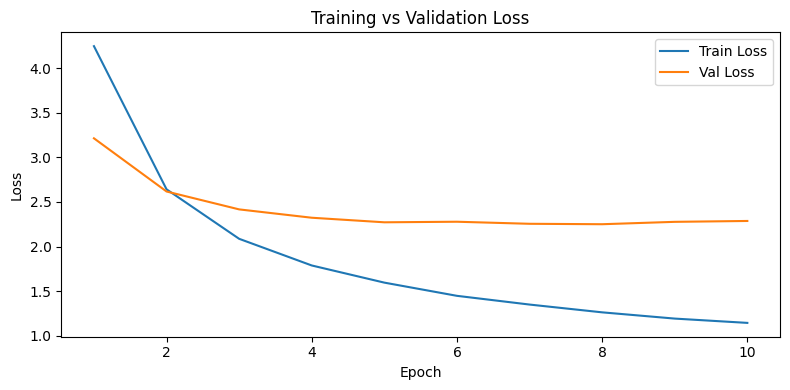

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label='Train Loss')
plt.plot(range(1, N_EPOCHS + 1), val_losses,   label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## 5. Translation Function

In [10]:
# Load best model weights before translating
model.load_state_dict(torch.load('best_model.pt', map_location=device))
model.eval()


def translate(sentence, model, src_vocab, tgt_vocab,
              device, max_len=50):
    """
    Translate a single English sentence to Russian.

    Parameters
    ----------
    sentence : str or torch.Tensor
        Raw English string, or a pre-built 1D index tensor.

    Returns
    -------
    str  – predicted Russian sentence (space-joined tokens)
    """
    model.eval()

    # ---- Encode source ----
    if isinstance(sentence, str):
        sentence = clean_text(sentence)
        src_indices = src_vocab.encode(sentence)
        src_tensor  = torch.tensor(src_indices, dtype=torch.long,
                                   device=device).unsqueeze(1)  # (src_len, 1)
    else:
        # Assume already a 1-D LongTensor
        src_tensor = sentence.to(device).unsqueeze(1)

    with torch.no_grad():
        hidden, cell = model.encoder(src_tensor)

    # ---- Decode ----
    dec_input  = torch.tensor([tgt_vocab.word2idx[SOS_TOKEN]],
                               dtype=torch.long, device=device)
    eos_idx    = tgt_vocab.word2idx[EOS_TOKEN]
    result_ids = []

    for _ in range(max_len):
        with torch.no_grad():
            pred, hidden, cell = model.decoder(dec_input, hidden, cell)
        top_idx   = pred.argmax(dim=1)
        token_id  = top_idx.item()

        if token_id == eos_idx:
            break

        result_ids.append(token_id)
        dec_input = top_idx

    tokens = tgt_vocab.decode(result_ids)
    # Filter out special tokens
    tokens = [t for t in tokens if t not in (PAD_TOKEN, SOS_TOKEN, EOS_TOKEN, UNK_TOKEN)]
    return ' '.join(tokens)

In [11]:
# ---- Demo translations ----
test_sentences = [
    "hello how are you",
    "i love this city",
    "what is your name",
    "the weather is nice today",
]

print('=' * 60)
for sent in test_sentences:
    translation = translate(sent, model, en_vocab, ru_vocab, device)
    print(f'EN: {sent}')
    print(f'RU: {translation}')
    print('-' * 60)

# ---- Spot-check against training data ----
print('\nRandom samples from validation set:')
print('=' * 60)
for en_sent, ru_ref in random.sample(val_pairs, 5):
    translation = translate(en_sent, model, en_vocab, ru_vocab, device)
    print(f'EN  : {en_sent}')
    print(f'REF : {ru_ref}')
    print(f'PRED: {translation}')
    print('-' * 60)

EN: hello how are you
RU: ты
------------------------------------------------------------
EN: i love this city
RU: я люблю этот город
------------------------------------------------------------
EN: what is your name
RU: как твое
------------------------------------------------------------
EN: the weather is nice today
RU: сегодня погода погода
------------------------------------------------------------

Random samples from validation set:
EN  : i just want to rest
REF : я просто хочу отдохнуть
PRED: просто хочу отдохнуть
------------------------------------------------------------
EN  : why didnt you help tom today
REF : почему ты не помог сегодня тому
PRED: почему ты не помог тому
------------------------------------------------------------
EN  : let me know if i need to make any changes
REF : дай мне знать если нужно будет чтонибудь поменять
PRED: дайте мне знать мне понадобится мне какието
------------------------------------------------------------
EN  : tom drove off into the ni